### Imports & Chargement

In [39]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Style visuel
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Chargement des données
df = pd.read_csv("../data/application_merged.csv")

print("Shape :", df.shape)
df.head()

Shape : (307511, 184)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_AMT_CREDIT_LIMIT_ACTUAL_mean,CC_AMT_CREDIT_LIMIT_ACTUAL_max,CC_AMT_DRAWINGS_CURRENT_mean,CC_AMT_DRAWINGS_CURRENT_sum,CC_CNT_DRAWINGS_CURRENT_mean,CC_CNT_DRAWINGS_CURRENT_sum,CC_SK_DPD_mean,CC_SK_DPD_max,CC_SK_DPD_DEF_mean,CC_SK_DPD_DEF_max
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,270000.0,270000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Apperçu global

In [41]:
# Informations générales
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 184 entries, SK_ID_CURR to CC_SK_DPD_DEF_max
dtypes: float64(127), int64(41), object(16)
memory usage: 431.7+ MB


In [42]:
# Types de variables
df.dtypes.value_counts()

float64    127
int64       41
object      16
Name: count, dtype: int64

In [43]:
# Nombre de clients uniques
print("Clients uniques :", df["SK_ID_CURR"].nunique())
print("Doublons :", df.duplicated("SK_ID_CURR").sum())

Clients uniques : 307511
Doublons : 0


Le dataset contient une ligne par client et aucune duplication sur la clé `SK_ID_CURR`.
Les données fusionnées sont cohérentes.

### Analyse de la cible

In [44]:
# Répartition de TARGET
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [45]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

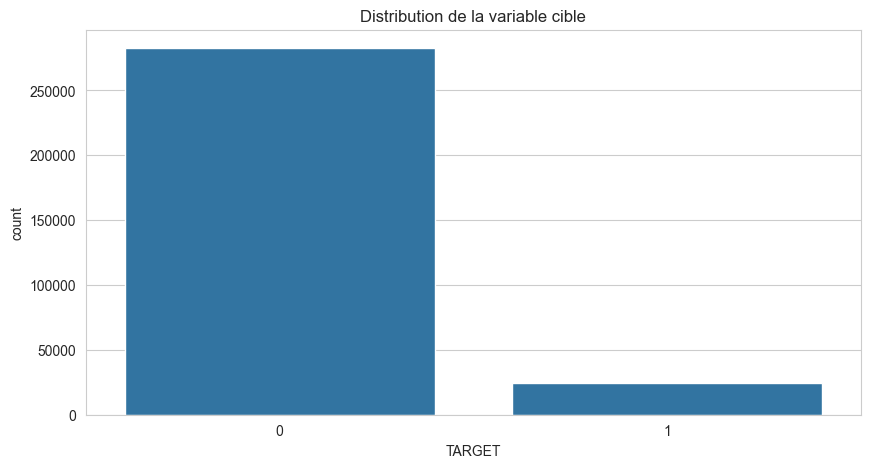

In [46]:
sns.countplot(data=df, x="TARGET")
plt.title("Distribution de la variable cible")
plt.show()

La variable cible est fortement déséquilibrée : la proportion de clients en défaut est faible (environ 8%).
Ce déséquilibre devra être pris en compte lors de la modélisation.

### Type de variables

In [47]:
df.dtypes.value_counts()

float64    127
int64       41
object      16
Name: count, dtype: int64

In [48]:
# Variables catégorielles
cat_cols = df.select_dtypes(include=["object"]).columns

print("Nombre de variables catégorielles :", len(cat_cols))
cat_cols.tolist()

Nombre de variables catégorielles : 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [49]:
# Nombre de modalités par variable catégorielle
for col in cat_cols:
    print(col, ":", df[col].nunique())

NAME_CONTRACT_TYPE : 2
CODE_GENDER : 3
FLAG_OWN_CAR : 2
FLAG_OWN_REALTY : 2
NAME_TYPE_SUITE : 7
NAME_INCOME_TYPE : 8
NAME_EDUCATION_TYPE : 5
NAME_FAMILY_STATUS : 6
NAME_HOUSING_TYPE : 6
OCCUPATION_TYPE : 18
WEEKDAY_APPR_PROCESS_START : 7
ORGANIZATION_TYPE : 58
FONDKAPREMONT_MODE : 4
HOUSETYPE_MODE : 3
WALLSMATERIAL_MODE : 7
EMERGENCYSTATE_MODE : 2


In [50]:
# Variables numériques
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Nombre de variables numériques :", len(num_cols))

Nombre de variables numériques : 168


### Valeurs manquantes

In [51]:
#Proportion de valeurs manquantes
missing = df.isnull().mean().sort_values(ascending=False)

missing[missing > 0].head(30)

CC_SK_DPD_DEF_mean                    0.717392
CC_SK_DPD_DEF_max                     0.717392
CC_CNT_DRAWINGS_CURRENT_mean          0.717392
CC_CNT_DRAWINGS_CURRENT_sum           0.717392
CC_AMT_DRAWINGS_CURRENT_sum           0.717392
CC_AMT_DRAWINGS_CURRENT_mean          0.717392
CC_AMT_BALANCE_max                    0.717392
CC_AMT_BALANCE_mean                   0.717392
CC_AMT_CREDIT_LIMIT_ACTUAL_mean       0.717392
CC_AMT_CREDIT_LIMIT_ACTUAL_max        0.717392
CC_SK_DPD_mean                        0.717392
CC_SK_DPD_max                         0.717392
CC_MONTHS_BALANCE_max                 0.717392
CC_MONTHS_BALANCE_min                 0.717392
BUREAU_BB_STATUS_0_mean               0.700073
BUREAU_BB_STATUS_3_mean               0.700073
BUREAU_BB_STATUS_5_mean               0.700073
BUREAU_BB_STATUS_C_mean               0.700073
BUREAU_BB_STATUS_1_mean               0.700073
BUREAU_BB_STATUS_2_mean               0.700073
BUREAU_BB_MONTHS_BALANCE_max_mean     0.700073
BUREAU_BB_MON

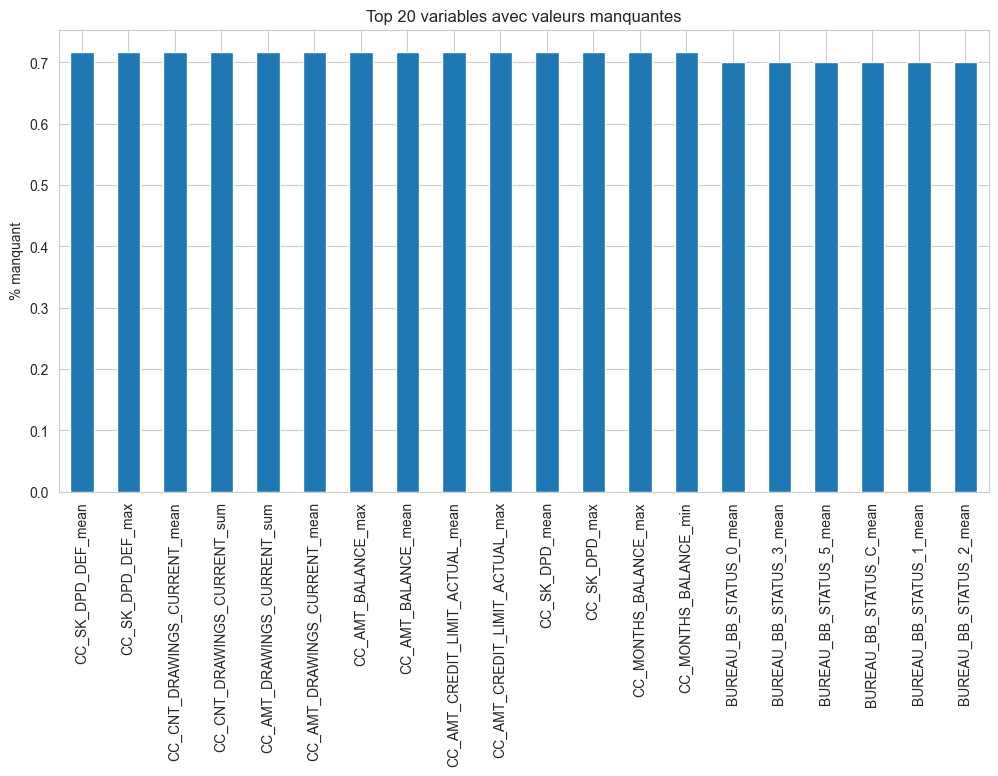

In [52]:
plt.figure(figsize=(12,6))
missing[missing > 0].head(20).plot(kind="bar")
plt.title("Top 20 variables avec valeurs manquantes")
plt.ylabel("% manquant")
plt.show()

In [53]:
# Nombre de colonnes avec de NaN
missing[missing > 0].shape

(129,)

Certaines variables présentent un taux élevé de valeurs manquantes. Une stratégie de gestion des NaN sera nécessaire lors du feature engineering.

### Analyse des outliers - Statistiques descriptives

In [54]:
desc = df.describe().T

# Variables avec max les plus élevés
desc[["mean","50%","std","min","max"]]\
.sort_values("max", ascending=False)\
.head(15)

,mean,50%,std,min,max
BUREAU_AMT_CREDIT_SUM_sum,1.955807e+06,961704.000000,4.101728e+06,0.00,1.017958e+09
BUREAU_AMT_CREDIT_SUM_DEBT_sum,6.406503e+05,169020.000000,1.633961e+06,-6981558.21,3.344983e+08
BUREAU_AMT_CREDIT_SUM_mean,3.780802e+05,195507.184091,8.916731e+05,0.00,1.980723e+08
AMT_INCOME_TOTAL,1.687979e+05,147150.000000,2.371231e+05,25650.00,1.170000e+08
BUREAU_AMT_CREDIT_SUM_DEBT_mean,1.603901e+05,44208.035000,5.266501e+05,-1083614.67,4.365000e+07
INST_AMT_PAYMENT_sum,6.785854e+05,318619.485000,9.161681e+05,0.00,2.553705e+07
INST_AMT_INSTALMENT_sum,6.724159e+05,328372.155000,8.800911e+05,0.00,2.327473e+07
CC_AMT_DRAWINGS_CURRENT_sum,2.783573e+05,146978.505000,4.450129e+05,0.00,1.846930e+07
PREV_AMT_APPLICATION_max,3.745905e+05,202500.000000,4.219951e+05,0.00,5.850000e+06
PREV_AMT_CREDIT_max,4.138656e+05,225000.000000,4.575384e+05,0.00,4.509688e+06


In [55]:
# Variables où max >> médiane
desc["max_median_ratio"] = desc["max"] / (desc["50%"] + 1)

desc[["50%","max","max_median_ratio"]]\
.sort_values("max_median_ratio", ascending=False)\
.head(15)

,50%,max,max_median_ratio
POS_SK_DPD_max,0.000000,4.231000e+03,4231.000000
POS_SK_DPD_DEF_max,0.000000,3.373000e+03,3373.000000
CC_SK_DPD_max,0.000000,2.831000e+03,2831.000000
CC_SK_DPD_DEF_max,0.000000,2.800000e+03,2800.000000
BUREAU_BB_MONTHS_BALANCE_size_sum,0.000000,2.657000e+03,2657.000000
POS_SK_DPD_mean,0.000000,2.622078e+03,2622.078431
BUREAU_AMT_CREDIT_SUM_DEBT_sum,169020.000000,3.344983e+08,1979.034151
POS_SK_DPD_DEF_mean,0.000000,1.740554e+03,1740.554455
CC_SK_DPD_mean,0.000000,1.386948e+03,1386.947917
CC_SK_DPD_DEF_mean,0.000000,1.309600e+03,1309.600000


In [56]:
# Variables avec min suspects
desc[["min","50%","max"]]\
.sort_values("min")\
.head(15)

,min,50%,max
BUREAU_AMT_CREDIT_SUM_DEBT_sum,-6.981558e+06,169020.000000,3.344983e+08
BUREAU_AMT_CREDIT_SUM_DEBT_mean,-1.083615e+06,44208.035000,4.365000e+07
DAYS_BIRTH,-2.522900e+04,-15750.000000,-7.489000e+03
DAYS_REGISTRATION,-2.467200e+04,-4504.000000,0.000000e+00
DAYS_EMPLOYED,-1.791200e+04,-1213.000000,3.652430e+05
DAYS_ID_PUBLISH,-7.197000e+03,-3254.000000,0.000000e+00
DAYS_LAST_PHONE_CHANGE,-4.292000e+03,-757.000000,0.000000e+00
INST_DAYS_ENTRY_PAYMENT_max,-3.071000e+03,-66.000000,-1.000000e+00
INST_DAYS_ENTRY_PAYMENT_mean,-3.071000e+03,-807.581818,-3.000000e+00
CC_AMT_BALANCE_mean,-2.930233e+03,26793.606316,9.286863e+05


L’analyse statistique met en évidence plusieurs constats :

- Certaines variables financières présentent des valeurs maximales très élevées, cohérentes avec la présence de clients atypiques ou de montants cumulés.
- Les variables de retard (`SK_DPD`) sont très concentrées sur 0, avec quelques cas extrêmes, ce qui reflète une majorité de clients sans incident et une minorité fortement en retard.
- Les variables temporelles négatives correspondent à une logique métier (jours avant la demande de crédit).
- Quelques montants négatifs apparaissent dans certaines variables agrégées et devront être surveillés lors du preprocessing.

Ces constats justifient des traitements futurs : transformation logarithmique, winsorisation éventuelle, ou conservation selon les performances modèles.

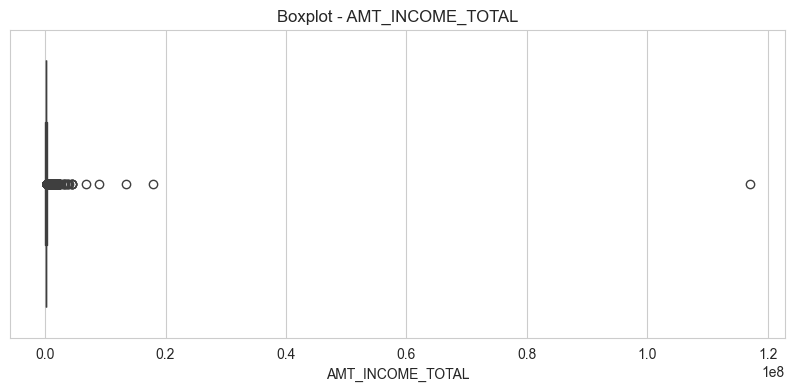

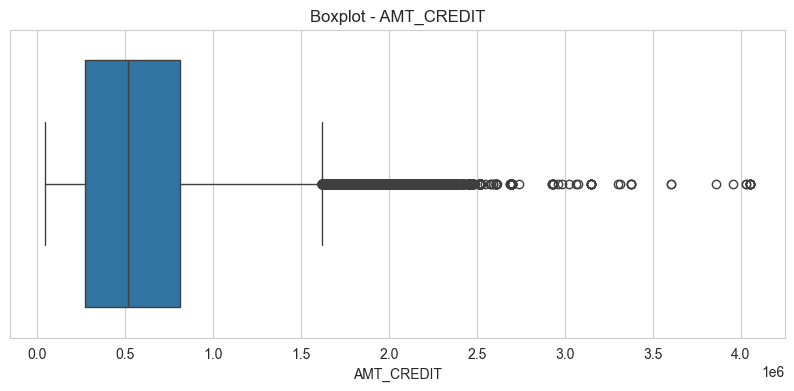

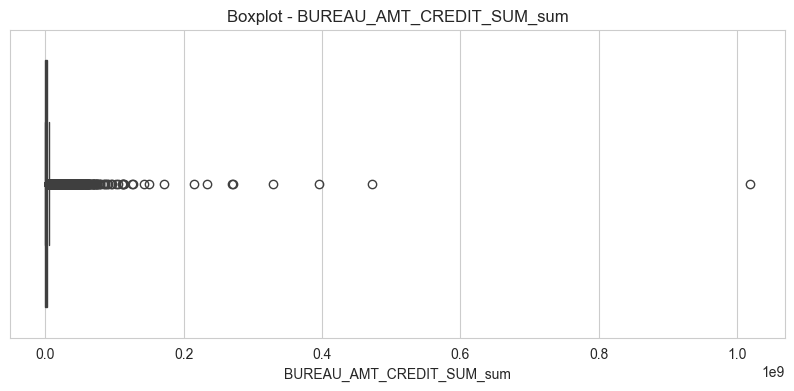

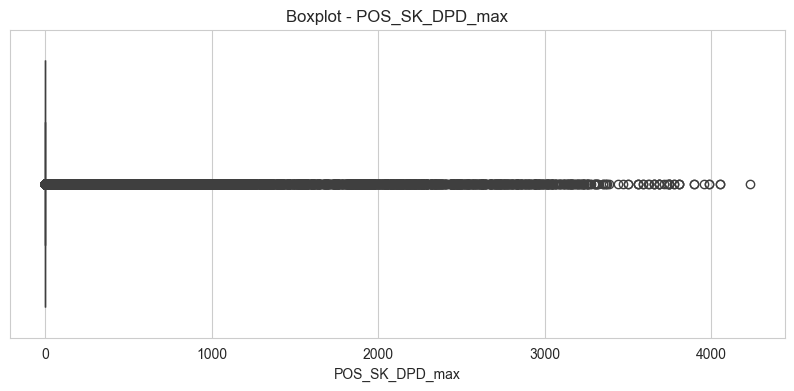

In [57]:
suspect_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "BUREAU_AMT_CREDIT_SUM_sum",
    "POS_SK_DPD_max"
]

for col in suspect_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

- **AMT_INCOME_TOTAL** : la majorité des revenus est concentrée sur des niveaux modestes à intermédiaires, avec quelques revenus extrêmement élevés, dont un cas très isolé proche de 117 millions.

- **AMT_CREDIT** : la distribution est plus étalée, avec plusieurs montants de crédit élevés jusqu’à environ 4 millions. 

- **BUREAU_AMT_CREDIT_SUM_sum** : les montants cumulés issus de l’historique bureau sont majoritairement faibles, avec quelques clients présentant des encours très importants.

- **POS_SK_DPD_max** : la variable est fortement concentrée sur 0 (absence de retard pour une majorité de clients), avec une longue traîne pouvant dépasser 4000 jours pour certains cas.

Ces observations suggèrent la présence de valeurs extrêmes réelles et potentiellement informatives, notamment pour les variables comportementales et financières.  

Dans un problème de scoring crédit, les observations extrêmes ne constituent pas nécessairement des anomalies ; elles peuvent correspondre à des profils atypiques ou risqués.

In [58]:
# Variables numériques pertinentes uniquement
num_cols = df.select_dtypes(include=["int64","float64"]).columns

valid_cols = [col for col in num_cols if df[col].nunique() > 10]

# Coefficients d'asymétrie (skewness)
# skew > 0 = queue à droite ; skew < 0 = queue à gauche
skewness = df[valid_cols].skew()

skewness.sort_values(ascending=False).head(15)

AMT_INCOME_TOTAL                   391.559654
AMT_REQ_CREDIT_BUREAU_QRT          134.365776
CC_SK_DPD_DEF_mean                 111.874718
POS_SK_DPD_DEF_mean                102.198336
CC_SK_DPD_DEF_max                   98.420339
POS_SK_DPD_DEF_max                  86.701209
BUREAU_AMT_CREDIT_SUM_sum           75.886871
BUREAU_AMT_CREDIT_SUM_mean          67.623382
BUREAU_AMT_CREDIT_SUM_DEBT_sum      38.905720
BUREAU_BB_STATUS_3_mean             27.423827
BUREAU_BB_STATUS_4_mean             20.579758
POS_SK_DPD_mean                     20.125659
BUREAU_AMT_CREDIT_SUM_DEBT_mean     19.609157
BUREAU_BB_STATUS_5_mean             19.034756
INST_AMT_INSTALMENT_mean            18.637978
dtype: float64

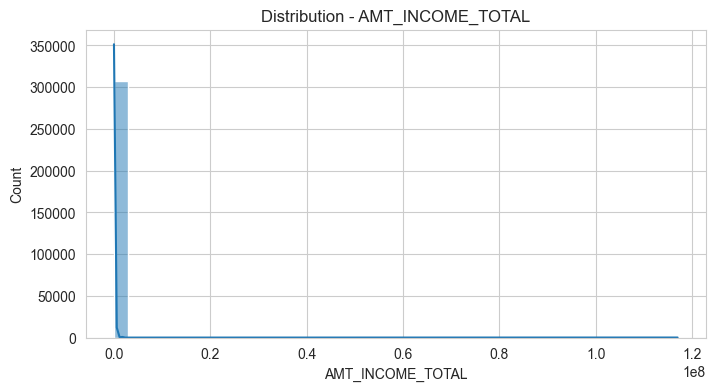

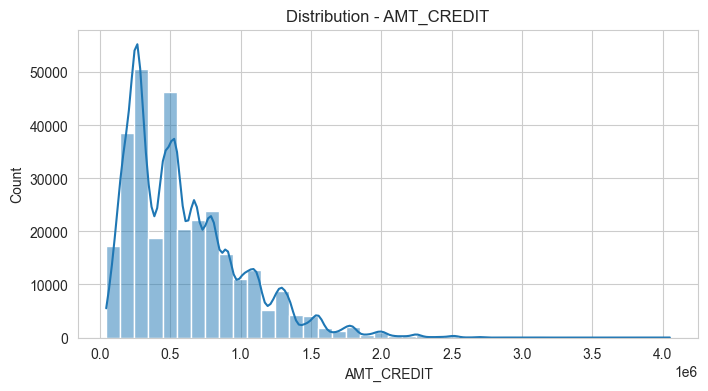

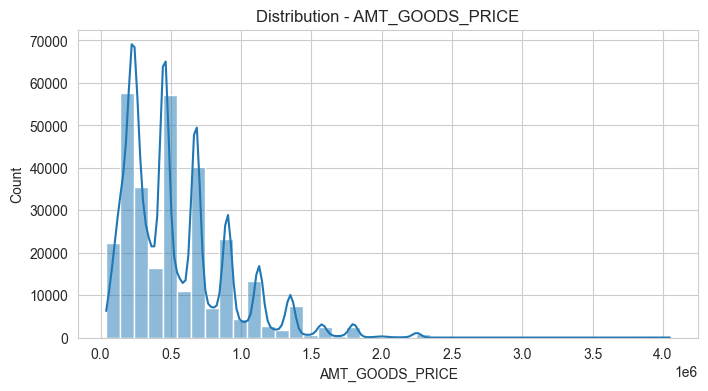

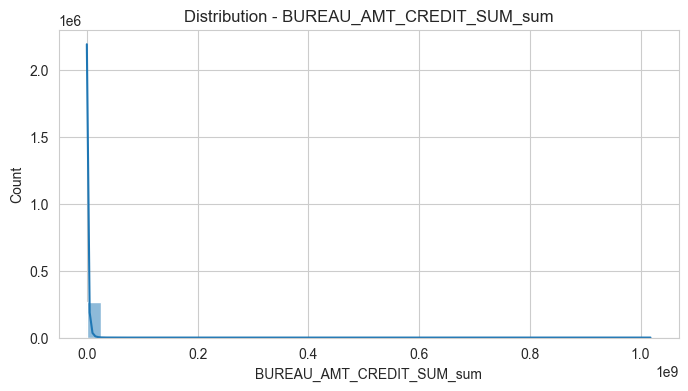

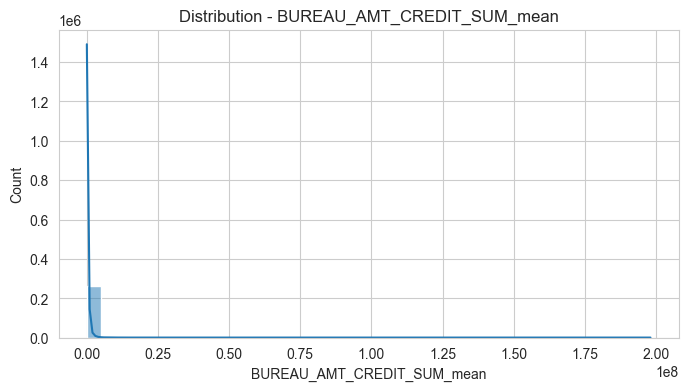

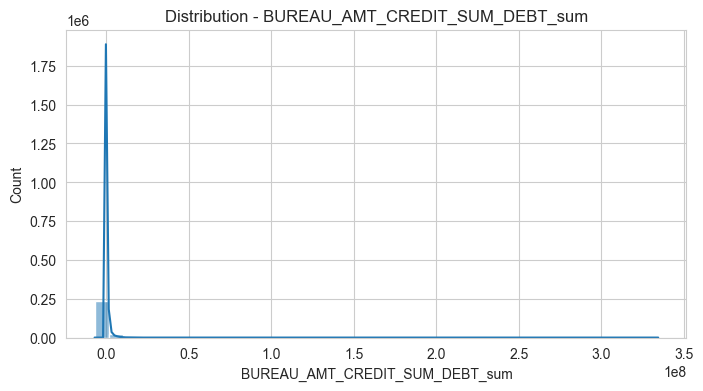

In [59]:
hist_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "BUREAU_AMT_CREDIT_SUM_sum",
    "BUREAU_AMT_CREDIT_SUM_mean",
    "BUREAU_AMT_CREDIT_SUM_DEBT_sum"
]

for col in hist_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution - {col}")
    plt.show()

L’analyse de l’asymétrie confirme toutefois que plusieurs variables financières présentent de longues traînes importantes (asymétries énormes > 10). Une approche prudente sera privilégiée : conserver les variables brutes afin de préserver l’information initiale, tout en créant des versions transformées (logarithmiques) pour les variables fortement asymétriques afin de réduire l'influence des valeurs extrêmes et améliorer la modélisation. L’intérêt de ces transformations sera ensuite évalué lors de la modélisation.

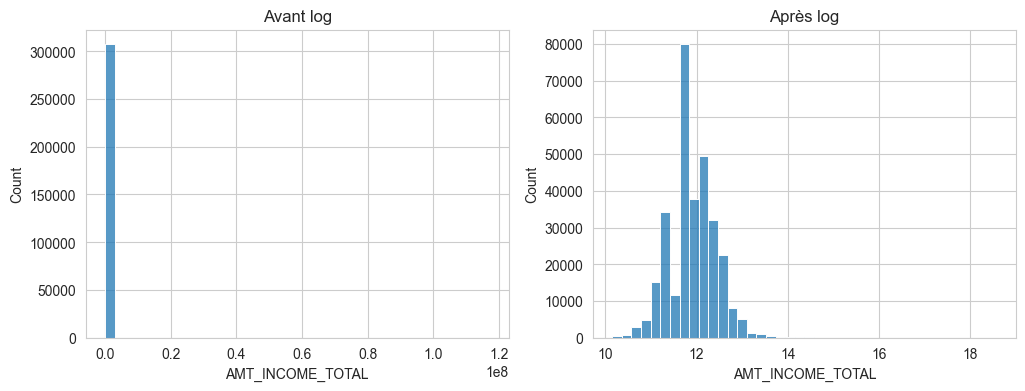

In [60]:
# Exemple avant/après log
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df["AMT_INCOME_TOTAL"], bins=40)
plt.title("Avant log")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df["AMT_INCOME_TOTAL"]), bins=40)
plt.title("Après log")

plt.show()

L’exemple ci-dessus illustre l’intérêt potentiel d’une transformation logarithmique sur les variables fortement asymétriques. Avant transformation, la distribution est concentrée sur de faibles valeurs avec quelques observations extrêmes très élevées. Après transformation, la distribution devient plus équilibrée et plus exploitable pour certains modèles sensibles à l’échelle ou à l’asymétrie. Des variables transformées seront donc bien créées dans la phase de feature engineering, tout en conservant les variables brutes.

### Variables vs TARGET

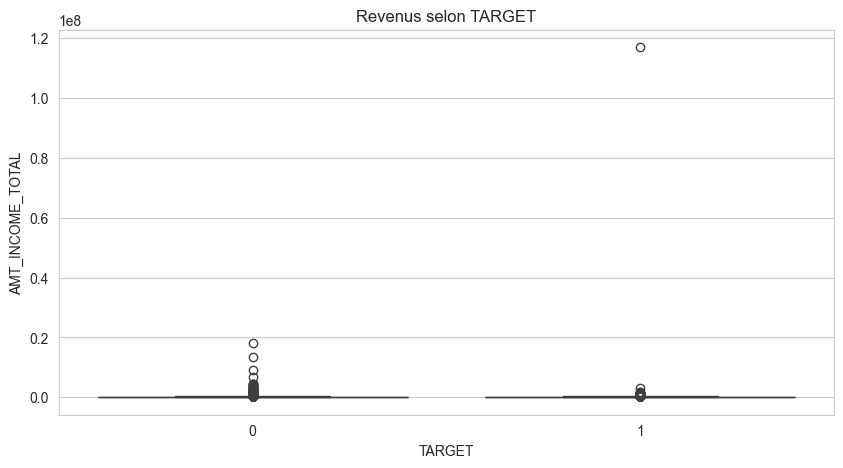

In [61]:
# Revenus
sns.boxplot(data=df, x="TARGET", y="AMT_INCOME_TOTAL")
plt.title("Revenus selon TARGET")
plt.show()

Les distributions sont proches entre les deux classes, mais les clients en défaut semblent légèrement plus concentrés sur les revenus modestes.

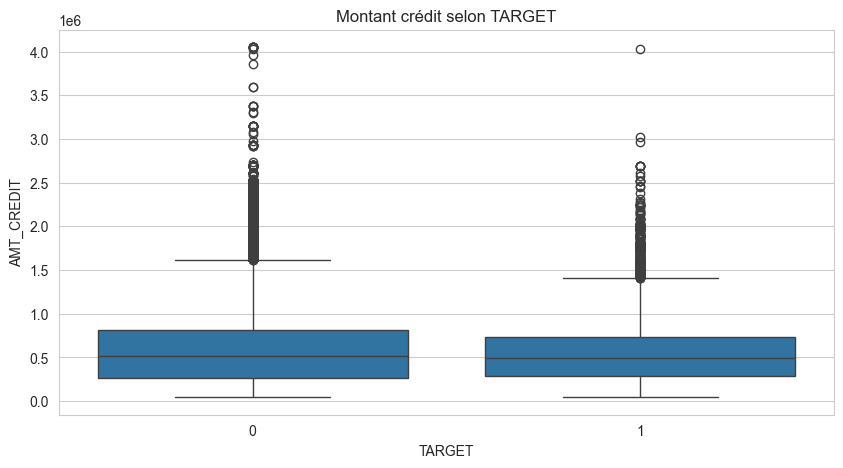

In [62]:
# Crédit
sns.boxplot(data=df, x="TARGET", y="AMT_CREDIT")
plt.title("Montant crédit selon TARGET")
plt.show()

Les montants empruntés sont globalement comparables entre les deux groupes, avec une légère dispersion plus faible chez les clients en défaut.

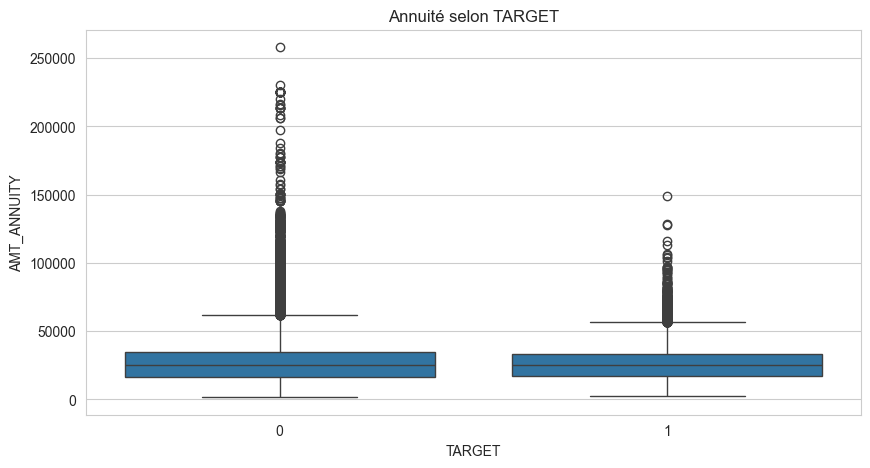

In [63]:
# Annuité
sns.boxplot(data=df, x="TARGET", y="AMT_ANNUITY")
plt.title("Annuité selon TARGET")
plt.show()

In [76]:
df.groupby("TARGET")["AMT_ANNUITY"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
TARGET,,,,,
0,27163.623349,24876.0,14658.307178,1615.5,258025.5
1,26481.744290,25263.0,12450.676999,2722.5,149211.0


Les clients solvables semblent davantage présents parmi les dossiers aux annuités les plus élevées, suggérant qu’un niveau élevé de mensualité n’implique pas nécessairement un risque accru.

In [64]:
# Analyse de l'âge
# Création variable âge
df["AGE"] = -df["DAYS_BIRTH"] / 365

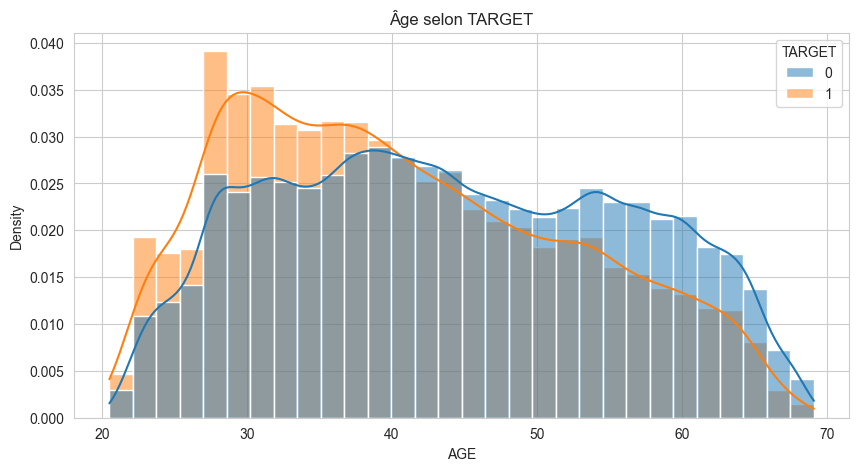

In [65]:
sns.histplot(data=df, x="AGE", hue="TARGET", bins=30, kde=True, stat="density", common_norm=False)
plt.title("Âge selon TARGET")
plt.show()

Les profils plus jeunes semblent légèrement plus exposés au défaut.

In [66]:
# Analyse emploi
# Valeur aberrante connue
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

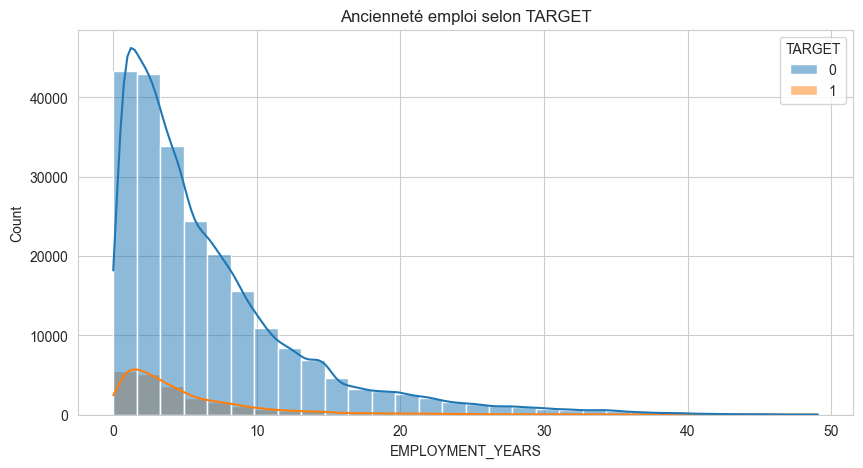

In [67]:
sns.histplot(data=df, x="EMPLOYMENT_YEARS", hue="TARGET", bins=30, kde=True)
plt.title("Ancienneté emploi selon TARGET")
plt.show()

Le défaut semble davantage concentré chez les clients ayant une ancienneté professionnelle plus faible.

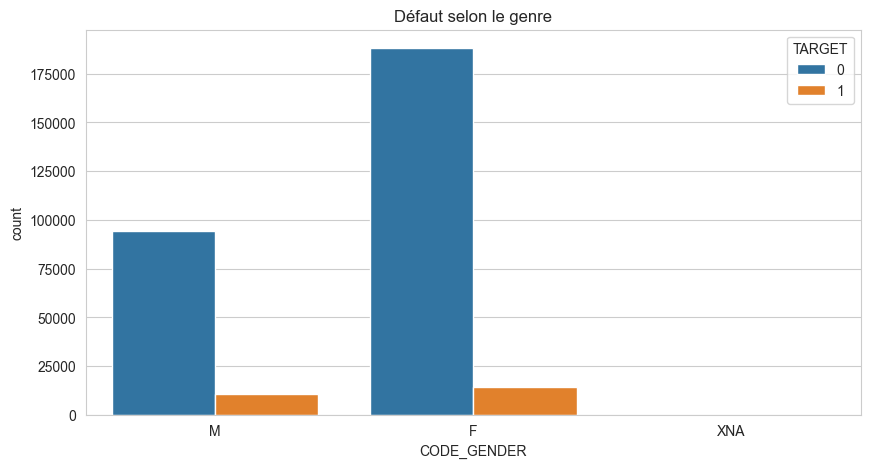

In [68]:
# Sexe
sns.countplot(data=df, x="CODE_GENDER", hue="TARGET")
plt.title("Défaut selon le genre")
plt.show()

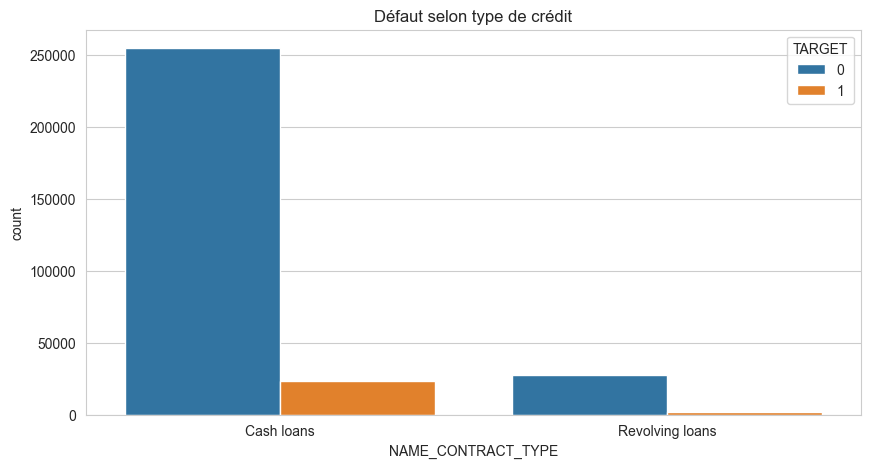

In [69]:
# Type de contrat
sns.countplot(data=df, x="NAME_CONTRACT_TYPE", hue="TARGET")
plt.title("Défaut selon type de crédit")
plt.show()

In [ ]:
# Taux de défaut moyen par type de contrat
default_rate = df.groupby("NAME_CONTRACT_TYPE")["TARGET"].mean().sort_values(ascending=False)
default_rate

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

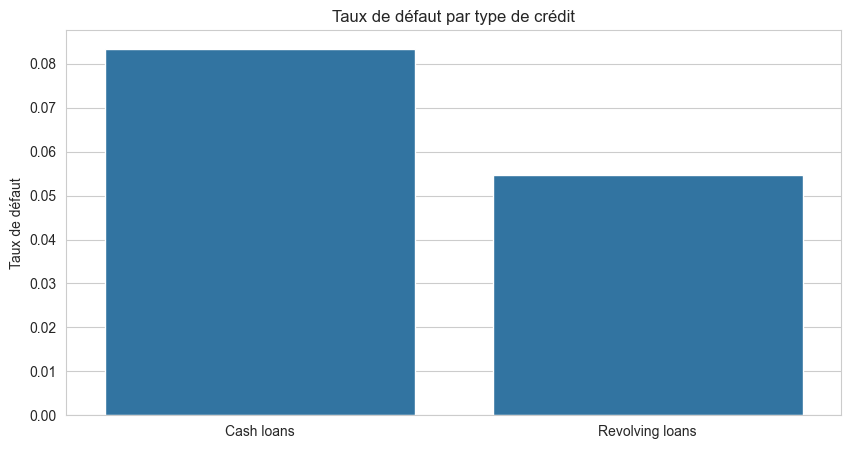

In [ ]:
# Visualisation du taux de défaut selon le type de crédit
sns.barplot(
    x=default_rate.index,
    y=default_rate.values
)

plt.title("Taux de défaut par type de crédit")
plt.ylabel("Taux de défaut")
plt.xlabel("")
plt.show()

Les Cash loans affichent un taux de défaut supérieur aux Revolving loans. Le type de contrat pourrait donc constituer une variable explicative pertinente du risque de défaut.

- Cash loans = prêt classique avec montant fixe versé une fois
- Revolving loans = Reserve réutilisable

Le taux de défaut plus élevé des Cash loans pourrait refléter des montants plus élevés et des modalités de remboursement moins flexibles que les crédits renouvelables.

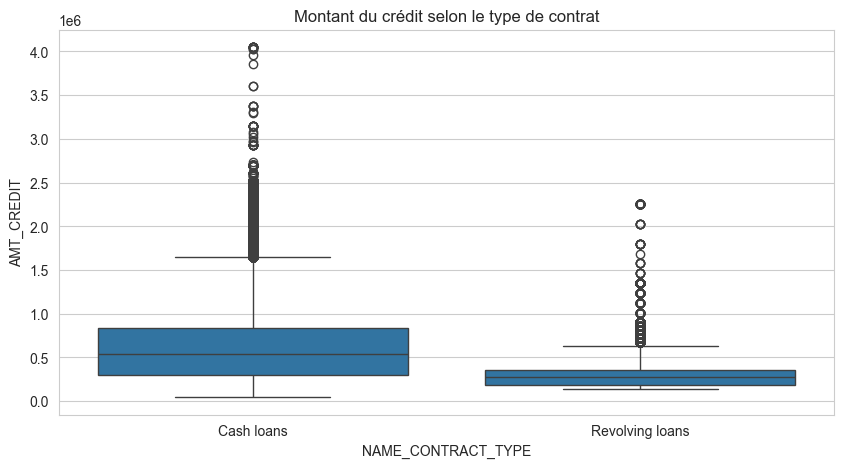

In [79]:
# Montant de crédit par type de contrat
sns.boxplot(
    data=df,
    x="NAME_CONTRACT_TYPE",
    y="AMT_CREDIT"
)

plt.title("Montant du crédit selon le type de contrat")
plt.show()

Les Cash loans présentent en effet des montants médians nettement plus élevés et une dispersion plus importante que les Revolving loans. Ils semblent donc correspondre à des engagements financiers plus conséquents.

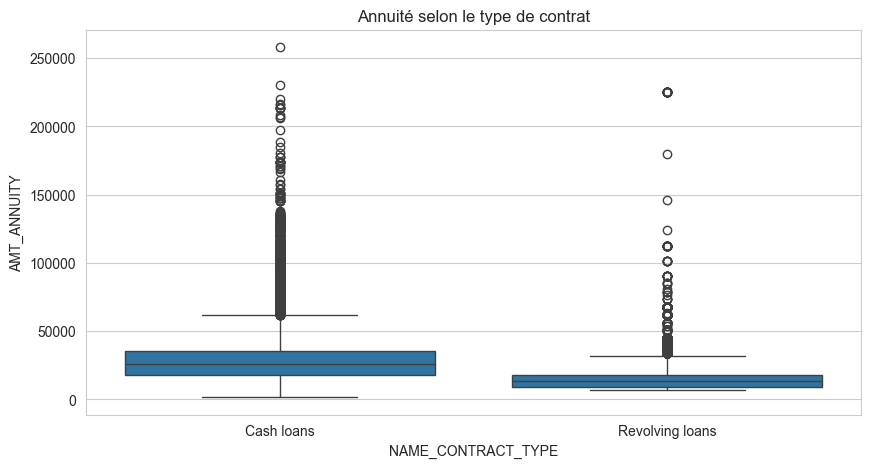

In [80]:
# Annuité par type de contrat
sns.boxplot(
    data=df,
    x="NAME_CONTRACT_TYPE",
    y="AMT_ANNUITY"
)

plt.title("Annuité selon le type de contrat")
plt.show()

Les annuités associées aux Cash loans sont globalement aussi plus élevées que celles des Revolving loans, suggérant une charge de remboursement plus importante.

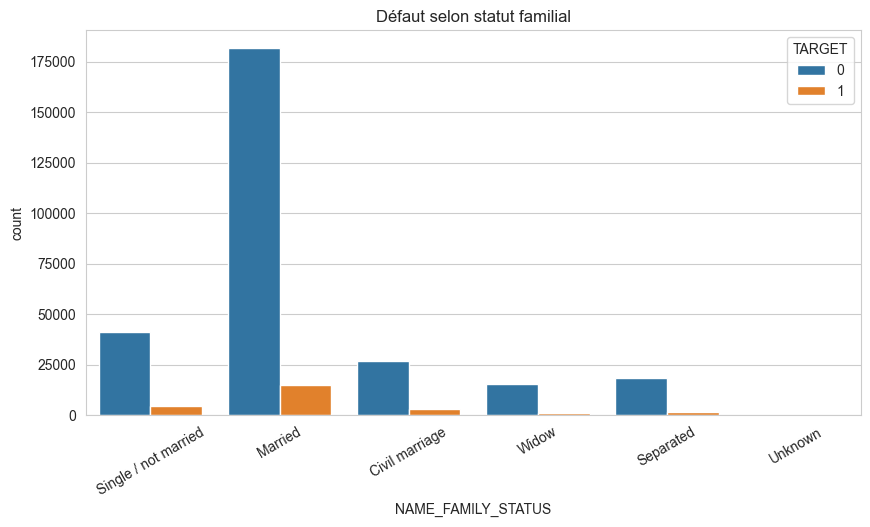

In [70]:
# Statut familial
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="NAME_FAMILY_STATUS", hue="TARGET")
plt.xticks(rotation=30)
plt.title("Défaut selon statut familial")
plt.show()

### Corrélations avec la TARGET

In [ ]:
# Corrélations entre variables numériques et la cible
corr = df.corr(numeric_only=True)["TARGET"].sort_values()

In [ ]:
# Corrélations positives les plus fortes
corr.tail(15)

DAYS_LAST_PHONE_CHANGE               0.055218
POS_MONTHS_BALANCE_min               0.055307
CC_AMT_DRAWINGS_CURRENT_mean         0.058732
REGION_RATING_CLIENT                 0.058899
REGION_RATING_CLIENT_W_CITY          0.060893
BUREAU_BB_STATUS_1_mean              0.061183
CC_MONTHS_BALANCE_min                0.061359
CC_AMT_BALANCE_max                   0.068798
DAYS_EMPLOYED                        0.074958
DAYS_BIRTH                           0.078239
CC_CNT_DRAWINGS_CURRENT_mean         0.082520
CC_AMT_BALANCE_mean                  0.087177
BUREAU_BB_MONTHS_BALANCE_min_mean    0.089038
BUREAU_DAYS_CREDIT_mean              0.089729
TARGET                               1.000000
Name: TARGET, dtype: float64

In [ ]:
# Corrélations négatives les plus fortes
corr.head(15)

EXT_SOURCE_3                         -0.178919
EXT_SOURCE_2                         -0.160472
EXT_SOURCE_1                         -0.155317
BUREAU_BB_MONTHS_BALANCE_size_mean   -0.080193
AGE                                  -0.078239
EMPLOYMENT_YEARS                     -0.074958
BUREAU_BB_STATUS_C_mean              -0.055936
FLOORSMAX_AVG                        -0.044003
FLOORSMAX_MEDI                       -0.043768
FLOORSMAX_MODE                       -0.043226
AMT_GOODS_PRICE                      -0.039645
REGION_POPULATION_RELATIVE           -0.037227
PREV_AMT_ANNUITY_mean                -0.034871
ELEVATORS_AVG                        -0.034199
ELEVATORS_MEDI                       -0.033863
Name: TARGET, dtype: float64

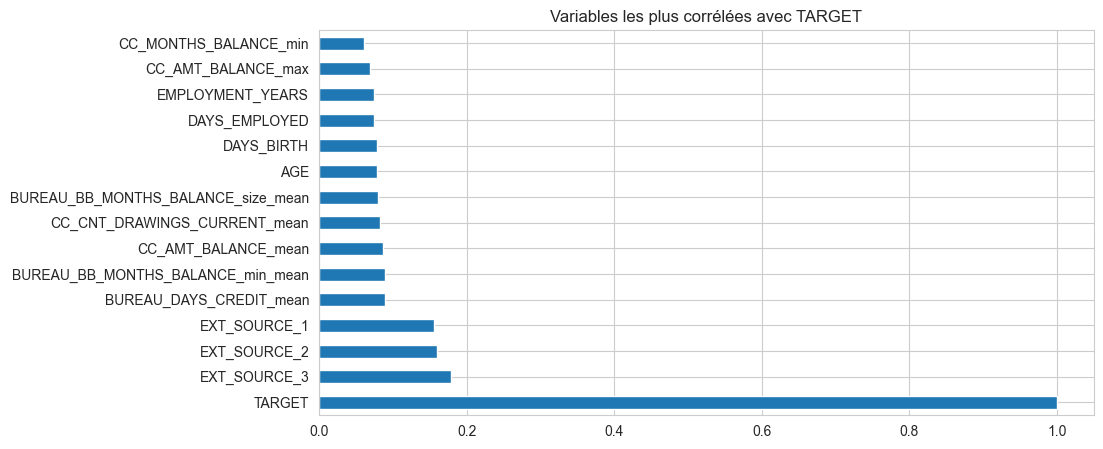

In [ ]:
# Variables les plus corrélées (valeur absolue)
top_corr = corr.abs().sort_values(ascending=False).head(15)

top_corr.plot(kind="barh")
plt.title("Variables les plus corrélées avec TARGET")
plt.show()

Les variables EXT_SOURCE_1, 2 et 3 sont les plus corrélées avec la target. Elles semblent résumer efficacement le niveau de risque du client. Des scores élevés sont associés à un risque plus faible.

Les corrélations observées sont globalement faibles à modérées, ce qui suggère un phénomène multifactoriel.
Aucune variable seule ne semble suffisante pour expliquer la target, ce qui justifie l’usage de modèles capables de combiner plusieurs signaux.

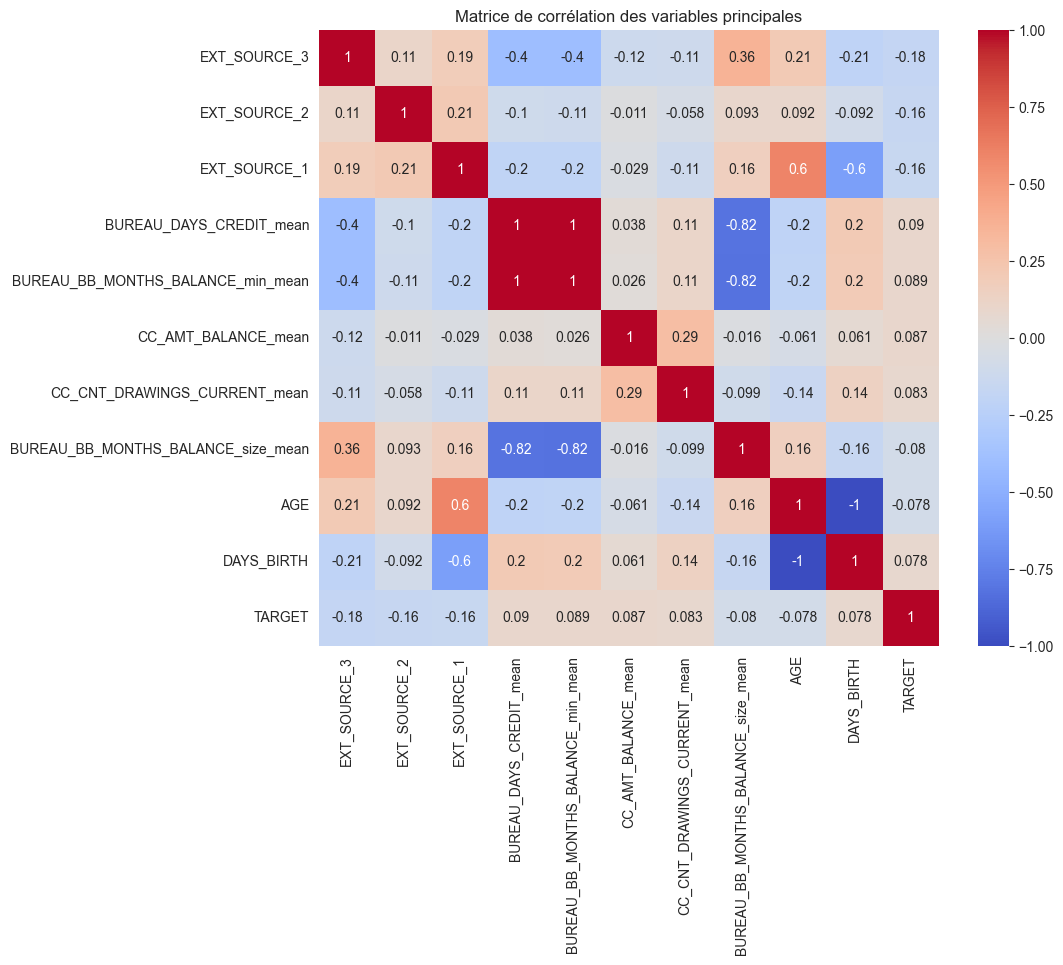

In [82]:
# Matrice de corrélation
top_vars = corr.drop("TARGET").abs().sort_values(ascending=False).head(10).index.tolist()

cols = top_vars + ["TARGET"]

plt.figure(figsize=(10,8))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables principales")
plt.show()

La matrice met en évidence certaines redondances (AGE/DAYS_BIRTH, BUREAU_DAYS_CREDIT_mean/BUREAU_BB_MONTHS_BALANCE_min_mean). Cette structure sera prise en compte lors du preprocessing et du choix des modèles.

## Conclusion

Le dataset fusionné est cohérent et exploitable.

L’EDA met en évidence :

- un fort déséquilibre de classes
- des valeurs manquantes importantes
- plusieurs variables financières asymétriques avec valeurs extrêmes
- des premières hypothèses explicatives intéressantes
- certaines redondances entre variables qui pourront être traitées au preprocessing

Le dataset est désormais prêt pour la phase de feature engineering puis de modélisation.